# Freight Rate Prediction: EDA, Feature Engineering, XGBoost Models and Report

**Target:** `posted_rate` | **Model:** XGBoost Regressor

This notebook runs three experiments and writes the Word report automatically, using the real numbers it computes:

1. **Model A**: trained on all but the last 3 days of `train_test.csv`, tested on those 3 days
2. **Model B**: random 80/20 split of `train_test.csv`
3. **Model C**: final model trained on all of `train_test.csv`, used to predict `validation.csv` and `december_chart_inputs.csv`

Upload the `data/` folder to Colab (or change `DATA_DIR`) and run the cells in order.

## 0. Setup

In [1]:
%pip install -q xgboost python-docx

import os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100); pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

DATA_DIR = "data"            # folder containing the CSV files
OUT_DIR  = "outputs"         # predictions, figures and the report are saved here
FIG_DIR  = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

SEED = 42
TARGET, ID_COL = "posted_rate", "load_id"
HOLDOUT_DAYS = 3             # Model A: last N days = test set
EARLY_STOP_DAYS = 7          # Model A: the N days before = early-stopping set

R = {}                       # facts collected along the way, used to write the report

def savefig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=130, bbox_inches="tight")

def haversine(lat1, lon1, lat2, lon2):
    """Straight-line distance in miles between two lat/lon points."""
    R_ = 3958.8
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi, dl = p2 - p1, np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return 2 * R_ * np.arcsin(np.sqrt(a))

## 1. Load data

In [2]:
train_full = pd.read_csv("train-test.csv")
val        = pd.read_csv("validation.csv")
dec        = pd.read_csv("december-chart-inputs.csv")
template   = pd.read_csv("validation-predictions-template.csv")

for d in (train_full, val, dec):
    d["date"] = pd.to_datetime(d["date"])

R["n_train"], R["n_val"], R["n_dec"] = len(train_full), len(val), len(dec)
print("train_test:", train_full.shape, "| validation:", val.shape, "| december:", dec.shape)
display(train_full.head())
print(train_full.dtypes)
print("\nOnly in train:", set(train_full.columns) - set(val.columns))
print("Only in december:", set(dec.columns) - set(train_full.columns))

train_test: (48000, 14) | validation: (12000, 13) | december: (31, 7)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


load_id                 object
pickup                  object
delivery                object
pickup_lat             float64
pickup_lon             float64
delivery_lat           float64
delivery_lon           float64
distance               float64
equipment               object
weight                 float64
date            datetime64[ns]
market_index           float64
quote_signal           float64
posted_rate            float64
dtype: object

Only in train: {'posted_rate'}
Only in december: {'predicted_rate'}


## 2. Exploratory data analysis

### 2.1 Date ranges

In [3]:
for name, d in [("train", train_full), ("validation", val), ("december", dec)]:
    R[f"dates_{name}"] = (d["date"].min().date(), d["date"].max().date())
    print(f"{name:11s}", R[f"dates_{name}"][0], "->", R[f"dates_{name}"][1], "| distinct days:", d["date"].dt.normalize().nunique())

R["n_days_train"] = train_full["date"].dt.normalize().nunique()
R["has_time"] = bool(train_full["date"].dt.hour.nunique() > 1)
R["val_overlaps_train"] = bool(val["date"].min() <= train_full["date"].max() and val["date"].max() >= train_full["date"].min())
print("\nDate column contains a time of day:", R["has_time"])
print("Validation dates overlap the training period:", R["val_overlaps_train"])

train       2025-01-01 -> 2025-10-31 | distinct days: 304
validation  2025-11-01 -> 2025-12-31 | distinct days: 61
december    2025-12-01 -> 2025-12-31 | distinct days: 31

Date column contains a time of day: False
Validation dates overlap the training period: False


### 2.2 Missing values, duplicates and impossible values

In [4]:
feat_cols = [c for c in train_full.columns if c != TARGET]
miss = pd.DataFrame({
    "train_missing": train_full.isna().sum(),
    "train_pct": (train_full.isna().mean() * 100).round(2),
    "val_missing": val.isna().sum(),
    "dec_missing": dec.isna().sum(),
}).fillna(0)
miss = miss.drop(index=["predicted_rate"], errors="ignore")      # empty column the December file asks us to fill
miss = miss[(miss.train_missing > 0) | (miss.val_missing > 0) | (miss.dec_missing > 0)]
for c in ["train_missing", "val_missing", "dec_missing"]:
    miss[c] = miss[c].astype(int)
display(miss)
R["miss_table"] = miss

R["dup_rows"] = int(train_full.duplicated().sum())
R["dup_ids"] = int(train_full[ID_COL].duplicated().sum())
R["neg_weight"] = int((train_full["weight"] < 0).sum())
R["weight_cap"] = float(train_full["weight"].abs().max())
R["at_cap"] = int((train_full["weight"].abs() == R["weight_cap"]).sum())
R["zero_weight"] = int((train_full["weight"] == 0).sum())
R["neg_target"] = int((train_full[TARGET] <= 0).sum())
R["bad_distance"] = int((train_full["distance"] <= 0).sum())

print("Duplicate rows:", R["dup_rows"], "| duplicate load_id:", R["dup_ids"])
print("Negative weights:", R["neg_weight"], "| rows at max |weight| =", R["weight_cap"], ":", R["at_cap"], "| zero weights:", R["zero_weight"])
print("Target <= 0:", R["neg_target"], "| distance <= 0:", R["bad_distance"])
display(train_full[["weight", "distance", "market_index", "quote_signal", TARGET]].describe(percentiles=[.01, .25, .5, .75, .99]).T)

,train_missing,train_pct,val_missing,dec_missing
market_index,374,0.78,249,0
weight,300,0.62,165,0


Duplicate rows: 0 | duplicate load_id: 0
Negative weights: 292 | rows at max |weight| = 47500.0 : 1204 | zero weights: 0
Target <= 0: 0 | distance <= 0: 0


,count,mean,std,min,1%,25%,50%,75%,99%,max
weight,47700.0,31028.844004,9391.440620,-47500.00000,9801.960000,25800.00000,31436.50000,37018.000000,47500.000000,47500.00000
distance,48000.0,1135.856654,728.564416,70.00000,121.899000,550.40000,953.30000,1645.525000,3029.304000,3439.80000
market_index,47626.0,1.083387,0.168091,0.67639,0.782887,0.94967,1.05580,1.219590,1.407185,1.46778
quote_signal,48000.0,2.062468,0.291391,0.69228,1.304657,1.89103,2.05575,2.221685,2.883951,3.61035
posted_rate,48000.0,2373.980682,1486.493245,57.22000,327.168800,1251.55500,2030.76000,3330.750000,5972.834000,25533.00000


### 2.3 Target distribution

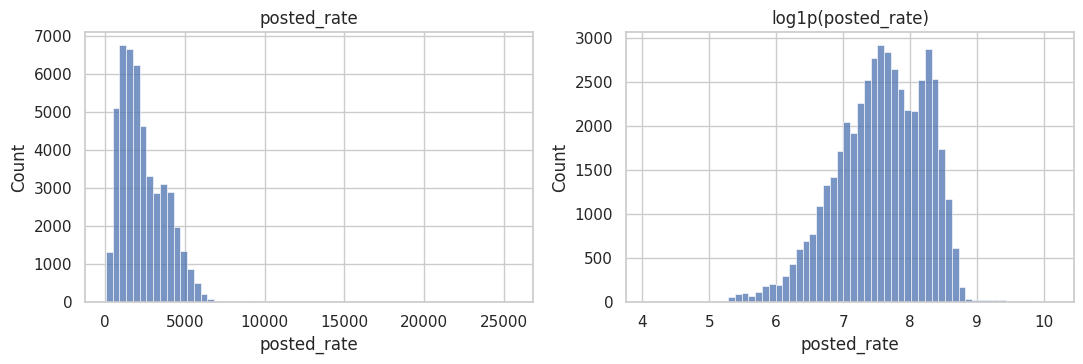

Skew: 1.902


In [5]:
R["target_skew"] = float(train_full[TARGET].skew())
R["target_desc"] = train_full[TARGET].describe()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
sns.histplot(train_full[TARGET], bins=60, ax=ax[0]); ax[0].set_title("posted_rate")
sns.histplot(np.log1p(train_full[TARGET]), bins=60, ax=ax[1]); ax[1].set_title("log1p(posted_rate)")
plt.tight_layout(); savefig("fig_target.png"); plt.show()
print("Skew:", round(R["target_skew"], 3))

### 2.4 Rate per mile, quote_signal and market_index

corr(rate/mile, quote_signal): 0.049
corr(rate, quote_signal x distance): 0.899
market_index std within a date: 0.0249 | std of daily means: 0.1665


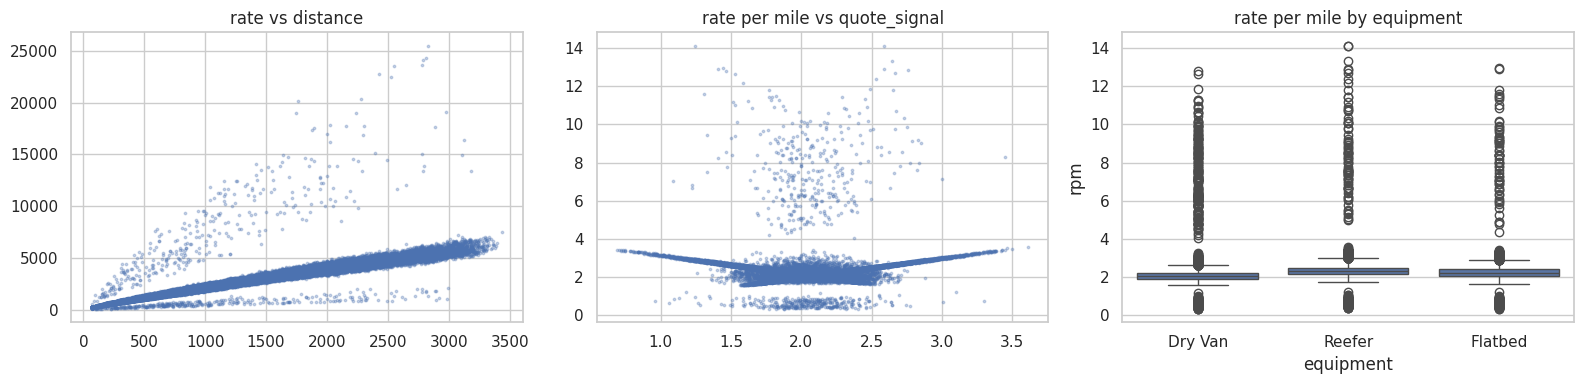

In [6]:
tmp = train_full.assign(rpm=train_full[TARGET] / train_full["distance"])
R["corr_rpm_quote"] = float(tmp["rpm"].corr(tmp["quote_signal"]))
R["corr_rate_quote_total"] = float(train_full[TARGET].corr(train_full["quote_signal"] * train_full["distance"]))
R["corr_rate_distance"] = float(train_full[TARGET].corr(train_full["distance"]))

g = train_full.groupby(train_full["date"].dt.normalize())["market_index"]
R["mi_within_std"], R["mi_across_std"] = float(g.std().mean()), float(g.mean().std())
print("corr(rate/mile, quote_signal):", round(R["corr_rpm_quote"], 3))
print("corr(rate, quote_signal x distance):", round(R["corr_rate_quote_total"], 3))
print("market_index std within a date:", round(R["mi_within_std"], 4), "| std of daily means:", round(R["mi_across_std"], 4))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].scatter(train_full["distance"], train_full[TARGET], s=3, alpha=.3); ax[0].set_title("rate vs distance")
ax[1].scatter(tmp["quote_signal"], tmp["rpm"], s=3, alpha=.3); ax[1].set_title("rate per mile vs quote_signal")
sns.boxplot(data=tmp, x="equipment", y="rpm", ax=ax[2]); ax[2].set_title("rate per mile by equipment")
plt.tight_layout(); savefig("fig_relations.png"); plt.show()

### 2.5 Locations: city set, coordinates and lanes

In [7]:
pu, de_ = set(train_full["pickup"]), set(train_full["delivery"])
R["n_cities"] = len(pu | de_)
R["coords_per_city"] = int(train_full.groupby("pickup")[["pickup_lat", "pickup_lon"]].nunique().max().max())
lanes = train_full.groupby(["pickup", "delivery"]).size()
R["n_lanes"], R["median_loads_lane"] = int(len(lanes)), float(lanes.median())

new_val = (set(val["pickup"]) | set(val["delivery"])) - (pu | de_)
new_dec = (set(dec["pickup"]) | set(dec["delivery"])) - (pu | de_)
affected = val["pickup"].isin(new_val) | val["delivery"].isin(new_val)
R["new_cities_val"], R["new_cities_dec"] = sorted(new_val), sorted(new_dec)
R["val_rows_new_city"], R["val_pct_new_city"] = int(affected.sum()), float(affected.mean() * 100)

print("Cities in train:", R["n_cities"], "| coordinate pairs per city (max):", R["coords_per_city"])
print("Unique lanes:", R["n_lanes"], "| median loads per lane:", R["median_loads_lane"])
print("Cities in validation never seen in train:", R["new_cities_val"])
print("Validation rows involving an unseen city:", R["val_rows_new_city"], f"({R['val_pct_new_city']:.1f}%)")
print("Cities in december never seen in train:", R["new_cities_dec"])

hav = haversine(train_full.pickup_lat, train_full.pickup_lon, train_full.delivery_lat, train_full.delivery_lon)
R["corr_dist_hav"] = float(train_full["distance"].corr(hav))
R["route_ratio_desc"] = (train_full["distance"] / hav.replace(0, np.nan)).describe()
print("corr(distance, haversine):", round(R["corr_dist_hav"], 4))
print(R["route_ratio_desc"].round(3))

Cities in train: 64 | coordinate pairs per city (max): 1
Unique lanes: 4014 | median loads per lane: 10.0
Cities in validation never seen in train: ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']
Validation rows involving an unseen city: 1447 (12.1%)
Cities in december never seen in train: []
corr(distance, haversine): 0.9995
count    48000.000
mean         1.195
std          0.144
min          1.058
25%          1.165
50%          1.182
75%          1.205
max          9.635
dtype: float64


### 2.6 Do validation  look like the training data?

In [8]:
rows = []
for c in ["distance", "weight", "market_index", "quote_signal"]:
    rows.append({"feature": c, "train_mean": train_full[c].mean(), "val_mean": val[c].mean(),
                 "train_std": train_full[c].std(), "val_std": val[c].std()})
for c in ["Dry Van", "Reefer"]:
    rows.append({"feature": f"share {c}", "train_mean": (train_full.equipment == c).mean(), "val_mean": (val.equipment == c).mean(),
                 "dec_mean": (dec.equipment == c).mean()})
drift = pd.DataFrame(rows).round(3)
R["drift"] = drift
display(drift)

,feature,train_mean,val_mean,train_std,val_std,dec_mean
0,distance,1135.857,1141.773,728.564,732.334,NaN
1,weight,31028.844,30506.636,9391.441,10572.590,NaN
2,market_index,1.083,0.927,0.168,0.074,NaN
3,quote_signal,2.062,2.051,0.291,0.220,NaN
4,share Dry Van,0.567,0.565,NaN,NaN,1.0
5,share Reefer,0.251,0.254,NaN,NaN,0.0


## 3. Data cleaning

Findings from the EDA drive the rules below. Fill values are **learned on the training part only** and re-used for validation and December, so nothing from the evaluation data leaks into the model.

- **`weight`**: negative values are sign errors, so take the absolute value. Missing values get the training median for the same `equipment` type. Flags record what was changed.
- **`market_index`**: it varies little within a date and a lot between dates, so a missing value is filled with the median of the other loads on the **same date**. A date with no value at all is filled by time interpolation, and a global median is the last resort.

In [9]:
def fit_cleaner(train_df):
    """Learn fill values from TRAINING data only."""
    w = train_df["weight"].abs()
    return {
        "weight_median_by_equip": w.groupby(train_df["equipment"]).median().to_dict(),
        "weight_median_global": float(w.median()),
        "mi_median_global": float(train_df["market_index"].median()),
    }

def clean_data(df, params):
    """Fix weight (negatives, NaN) and market_index (NaN: same-date median, then interpolation)."""
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])

    df["weight_missing"] = df["weight"].isna().astype(int)
    df["weight_was_negative"] = (df["weight"] < 0).astype(int)
    df["weight"] = df["weight"].abs()
    df["weight"] = (df["weight"]
                    .fillna(df["equipment"].map(params["weight_median_by_equip"]))
                    .fillna(params["weight_median_global"]))

    df["mi_missing"] = df["market_index"].isna().astype(int)
    day = df["date"].dt.normalize()
    daily = df.groupby(day)["market_index"].median()
    full = daily.reindex(pd.date_range(daily.index.min(), daily.index.max()))
    full = full.interpolate(method="time").bfill().ffill()
    df["market_index"] = (df["market_index"]
                          .fillna(day.map(full))
                          .fillna(params["mi_median_global"]))
    return df

# demonstration on the full training file
_p = fit_cleaner(train_full)
_c = clean_data(train_full, _p)
R["weights_fixed_neg"], R["weights_filled"], R["mi_filled"] = int(_c.weight_was_negative.sum()), int(_c.weight_missing.sum()), int(_c.mi_missing.sum())
R["nan_after_clean"] = int(_c[["weight", "market_index"]].isna().sum().sum())
R["weight_medians"] = {k: round(v) for k, v in _p["weight_median_by_equip"].items()}
print("Negative weights fixed:", R["weights_fixed_neg"], "| weights filled:", R["weights_filled"], "| market_index filled:", R["mi_filled"])
print("Weight medians by equipment:", R["weight_medians"])
print("Missing values left in weight/market_index after cleaning:", R["nan_after_clean"])

Negative weights fixed: 292 | weights filled: 300 | market_index filled: 374
Weight medians by equipment: {'Dry Van': 31444, 'Flatbed': 31532, 'Reefer': 31577}
Missing values left in weight/market_index after cleaning: 0


## 4. Feature engineering

City names (`pickup`, `delivery`) and `load_id` are **not** model inputs, because validation contains cities that never appear in training. The model uses coordinates and numeric load features instead, which exist for every city.

In [10]:
def bearing(lat1, lon1, lat2, lon2):
    """Direction of travel in radians."""
    p1, p2, dl = np.radians(lat1), np.radians(lat2), np.radians(lon2 - lon1)
    x = np.sin(dl) * np.cos(p2)
    y = np.cos(p1) * np.sin(p2) - np.sin(p1) * np.cos(p2) * np.cos(dl)
    return np.arctan2(x, y)

def add_cyclic(d, col, values, period):
    d[f"{col}_sin"] = np.sin(2 * np.pi * values / period)
    d[f"{col}_cos"] = np.cos(2 * np.pi * values / period)

equip_cats = sorted(train_full["equipment"].dropna().unique())
equip_map = {c: i for i, c in enumerate(equip_cats)}
print("Equipment map:", equip_map)

def add_features(df):
    d = df.copy()
    # load / distance features
    d["hav_dist"] = haversine(d.pickup_lat, d.pickup_lon, d.delivery_lat, d.delivery_lon)
    d["route_ratio"] = d["distance"] / d["hav_dist"].replace(0, np.nan)
    d["weight_per_mile"] = d["weight"] / d["distance"].replace(0, np.nan)
    d["quote_total"] = d["quote_signal"] * d["distance"]
    b = bearing(d.pickup_lat, d.pickup_lon, d.delivery_lat, d.delivery_lon)
    d["bearing_sin"], d["bearing_cos"] = np.sin(b), np.cos(b)
    d["equipment_code"] = d["equipment"].map(equip_map)

    # calendar features: day of week and day of month only
    add_cyclic(d, "dow", d["date"].dt.dayofweek, 7)     # 0-6, period 7
    add_cyclic(d, "dom", d["date"].dt.day - 1, 31)      # 0-30, period 31
    return d

FEATURES = [
    "pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon",
    "distance", "hav_dist", "route_ratio", "weight", "weight_per_mile",
    "market_index", "quote_signal", "quote_total",
    "bearing_sin", "bearing_cos", "equipment_code",
    "weight_missing", "weight_was_negative", "mi_missing",
    "dow_sin", "dow_cos", "dom_sin", "dom_cos",
]
R["features"] = FEATURES
print(len(FEATURES), "features")

def prepare(raw_fit, *others):
    """Fit the cleaner on raw_fit only, then clean + add features to raw_fit and every other frame."""
    params = fit_cleaner(raw_fit)
    return params, [add_features(clean_data(d, params)) for d in (raw_fit, *others)]

Equipment map: {'Dry Van': 0, 'Flatbed': 1, 'Reefer': 2}
22 features


### 4.1 Correlation matrix after feature engineering

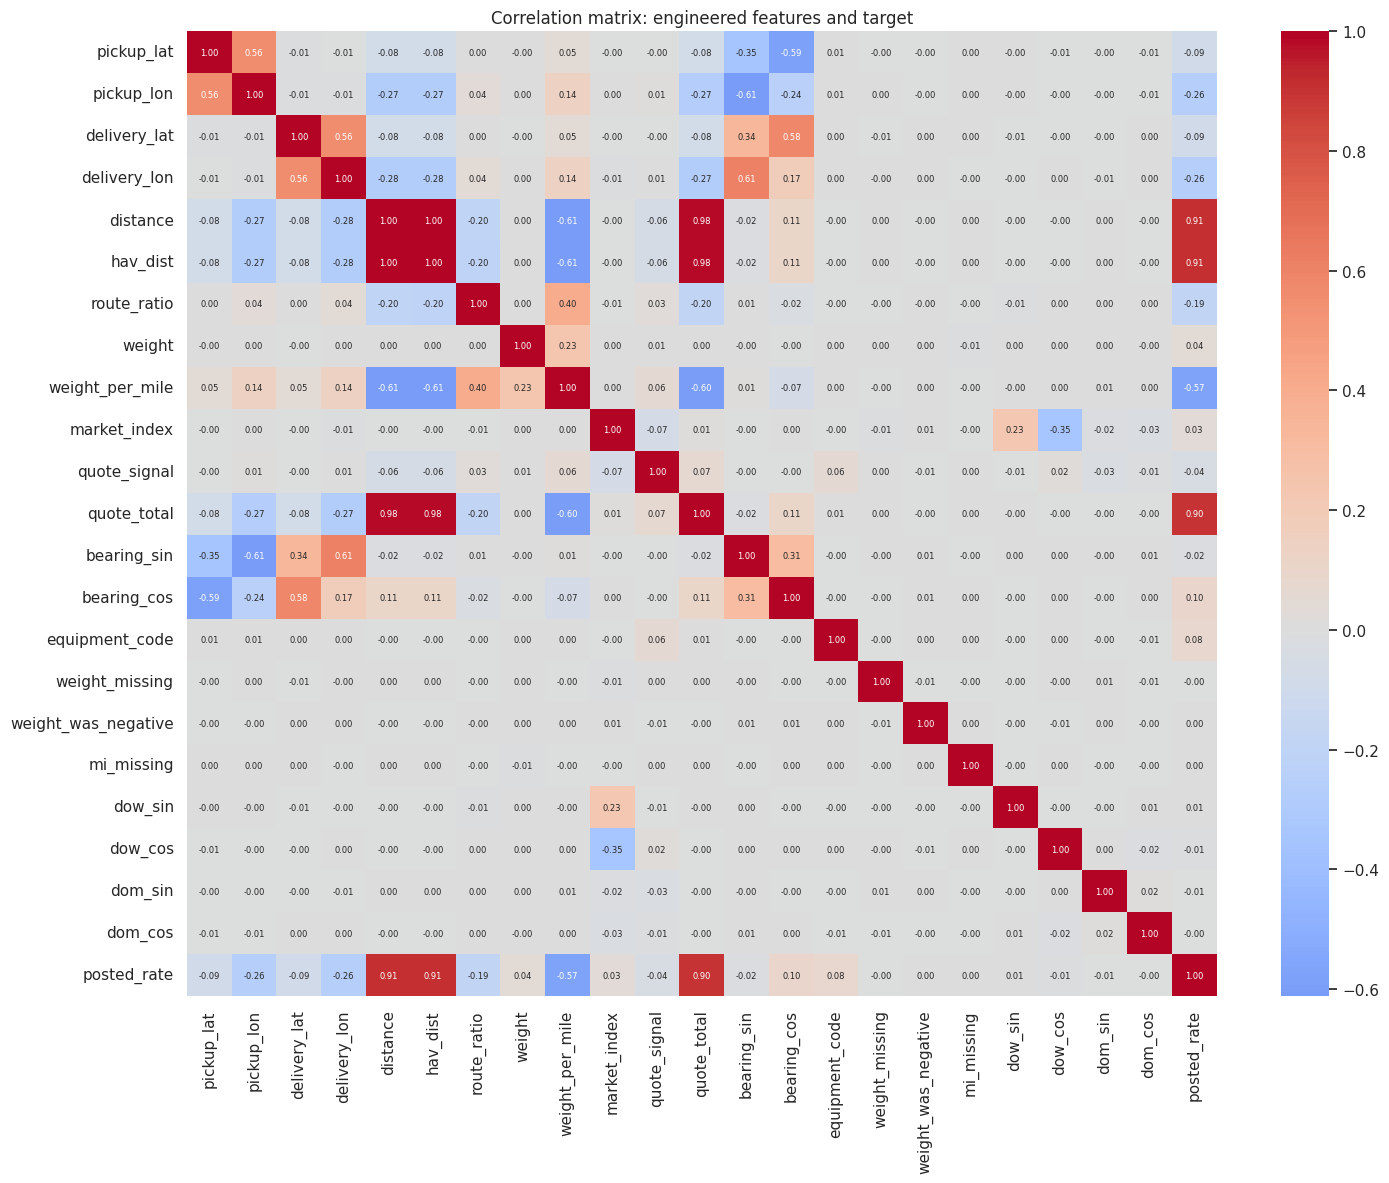

distance           0.909
hav_dist           0.908
quote_total        0.899
weight_per_mile   -0.569
delivery_lon      -0.257
pickup_lon        -0.255
route_ratio       -0.188
bearing_cos        0.099
delivery_lat      -0.092
pickup_lat        -0.091
Name: posted_rate, dtype: float64


In [11]:
_, (all_feat,) = prepare(train_full)
corr = all_feat[FEATURES + [TARGET]].corr()
plt.figure(figsize=(15, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 6})
plt.title("Correlation matrix: engineered features and target")
plt.tight_layout(); savefig("fig_corr.png"); plt.show()

R["top_corr"] = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).head(10).round(3)
print(R["top_corr"])

## 5. Metrics, baselines and training helper

Metrics are computed on the original rate scale: **MAE, RMSE, MAPE, WAPE, Bias, R²**. WAPE is the sum of absolute errors divided by the sum of actual values, which makes it stable for loads with small rates.

Two simple baselines give context for the model: `quote_signal × distance`, and the training median rate per mile × distance.

In [12]:
def metrics(y, p, name=""):
    y, p = np.asarray(y, float), np.asarray(p, float)
    return pd.Series({
        "MAE": mean_absolute_error(y, p),
        "RMSE": np.sqrt(mean_squared_error(y, p)),
        "MAPE_%": np.mean(np.abs((y - p) / y)) * 100,
        "WAPE_%": np.sum(np.abs(y - p)) / np.sum(np.abs(y)) * 100,
        "Bias": np.mean(p - y),
        "R2": r2_score(y, p),
    }, name=name)

XGB_PARAMS = dict(learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8,
                  min_child_weight=5, reg_lambda=1.0, tree_method="hist",
                  random_state=SEED, n_jobs=-1)
MAX_TREES, EARLY_ROUNDS = 3000, 100
R["xgb_params"] = XGB_PARAMS

def run_experiment(name, raw_fit, raw_early, raw_test):
    """Clean + featurize (cleaner fit on raw_fit only), train with early stopping on raw_early, score on raw_test."""
    _, (fit_f, early_f, test_f) = prepare(raw_fit, raw_early, raw_test)
    model = xgb.XGBRegressor(n_estimators=MAX_TREES, eval_metric="mae",
                             early_stopping_rounds=EARLY_ROUNDS, **XGB_PARAMS)
    model.fit(fit_f[FEATURES], fit_f[TARGET],
              eval_set=[(early_f[FEATURES], early_f[TARGET])], verbose=False)
    pred = model.predict(test_f[FEATURES])

    rpm_med = (fit_f[TARGET] / fit_f["distance"]).median()
    table = pd.concat([
        metrics(test_f[TARGET], pred, "XGBoost"),
        metrics(test_f[TARGET], test_f["quote_total"], "Baseline: quote_signal x distance"),
        metrics(test_f[TARGET], rpm_med * test_f["distance"], "Baseline: median rate/mile x distance"),
    ], axis=1).T.round(4)
    return dict(name=name, model=model, best_iter=model.best_iteration + 1, test=test_f, pred=pred,
                table=table, n_fit=len(fit_f), n_early=len(early_f), n_test=len(test_f))

def plot_results(res, fname):
    y, p = res["test"][TARGET].values, res["pred"]
    fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
    ax[0].scatter(y, p, s=4, alpha=.4)
    lims = [y.min(), y.max()]; ax[0].plot(lims, lims, "r--")
    ax[0].set_xlabel("Actual"); ax[0].set_ylabel("Predicted"); ax[0].set_title(f"{res['name']}: actual vs predicted")
    sns.histplot(p - y, bins=60, ax=ax[1]); ax[1].set_title("Residuals (predicted - actual)")
    ax[2].scatter(res["test"]["distance"], p - y, s=4, alpha=.4); ax[2].axhline(0, color="r")
    ax[2].set_xlabel("Distance"); ax[2].set_title("Residuals vs distance")
    plt.tight_layout(); savefig(fname); plt.show()

## 6. Model A: test on the last 3 days

Fit: 46464 | early-stopping: 1019 | test (last 3 days): 517 ('2025-10-29', '2025-10-31')
Best iteration: 91


,MAE,RMSE,MAPE_%,WAPE_%,Bias,R2
XGBoost,153.4918,751.7982,8.1540,6.4906,-67.0591,0.7800
Baseline: quote_signal x distance,436.1951,858.5443,23.3812,18.4452,-110.2194,0.7131
Baseline: median rate/mile x distance,273.2013,772.0964,13.9433,11.5528,-2.0234,0.7679


,rows,WAPE_%,MAPE_%
date,,,
2025-10-29,164.0,8.480,8.248
2025-10-30,177.0,6.042,9.914
2025-10-31,176.0,4.983,6.297


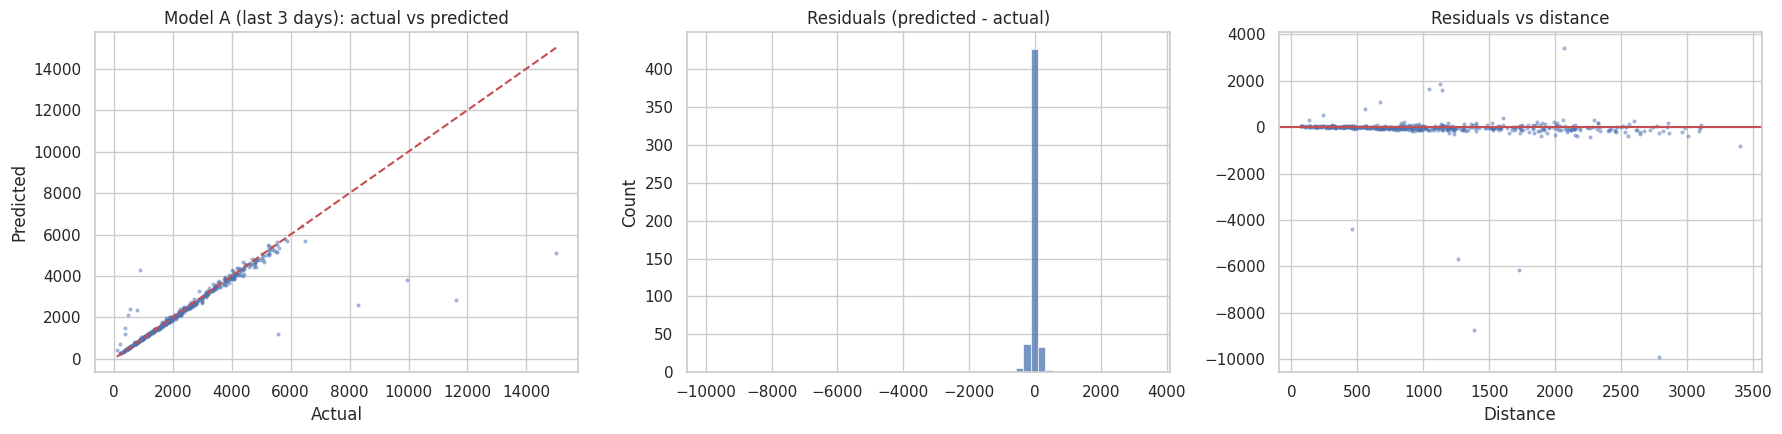

In [13]:
day = train_full["date"].dt.normalize()
dates = np.sort(day.unique())
hold_days  = dates[-HOLDOUT_DAYS:]
early_days = dates[-(HOLDOUT_DAYS + EARLY_STOP_DAYS):-HOLDOUT_DAYS]
A_fit   = train_full[~day.isin(np.concatenate([hold_days, early_days]))]
A_early = train_full[day.isin(early_days)]
A_test  = train_full[day.isin(hold_days)]
R["A_days"] = (str(pd.Timestamp(hold_days[0]).date()), str(pd.Timestamp(hold_days[-1]).date()))
print("Fit:", len(A_fit), "| early-stopping:", len(A_early), "| test (last", HOLDOUT_DAYS, "days):", len(A_test), R["A_days"])

resA = run_experiment("Model A (last 3 days)", A_fit, A_early, A_test)
R["A"] = resA["table"]; R["A_best_iter"] = resA["best_iter"]
R["A_sizes"] = (resA["n_fit"], resA["n_early"], resA["n_test"])
print("Best iteration:", resA["best_iter"])
display(resA["table"])

tmp = resA["test"][["date", TARGET]].assign(pred=resA["pred"])
perday = tmp.groupby(tmp["date"].dt.date).apply(lambda g: pd.Series({
    "rows": len(g),
    "WAPE_%": (g[TARGET] - g["pred"]).abs().sum() / g[TARGET].abs().sum() * 100,
    "MAPE_%": ((g[TARGET] - g["pred"]).abs() / g[TARGET]).mean() * 100})).round(3)
R["A_perday"] = perday.reset_index().rename(columns={"date": "day"})
R["A_perday"]["rows"] = R["A_perday"]["rows"].astype(int)
display(perday)
plot_results(resA, "fig_modelA.png")

## 7. Model B: random 80/20 split

Fit: 34560 | early-stopping: 3840 | test (20%): 9600
Best iteration: 120


,MAE,RMSE,MAPE_%,WAPE_%,Bias,R2
XGBoost,118.2524,536.8488,5.6077,4.9656,1.2805,0.8652
Baseline: quote_signal x distance,224.9654,614.1799,11.2138,9.4466,-43.3565,0.8236
Baseline: median rate/mile x distance,256.5750,603.4803,11.4479,10.7739,67.6395,0.8297


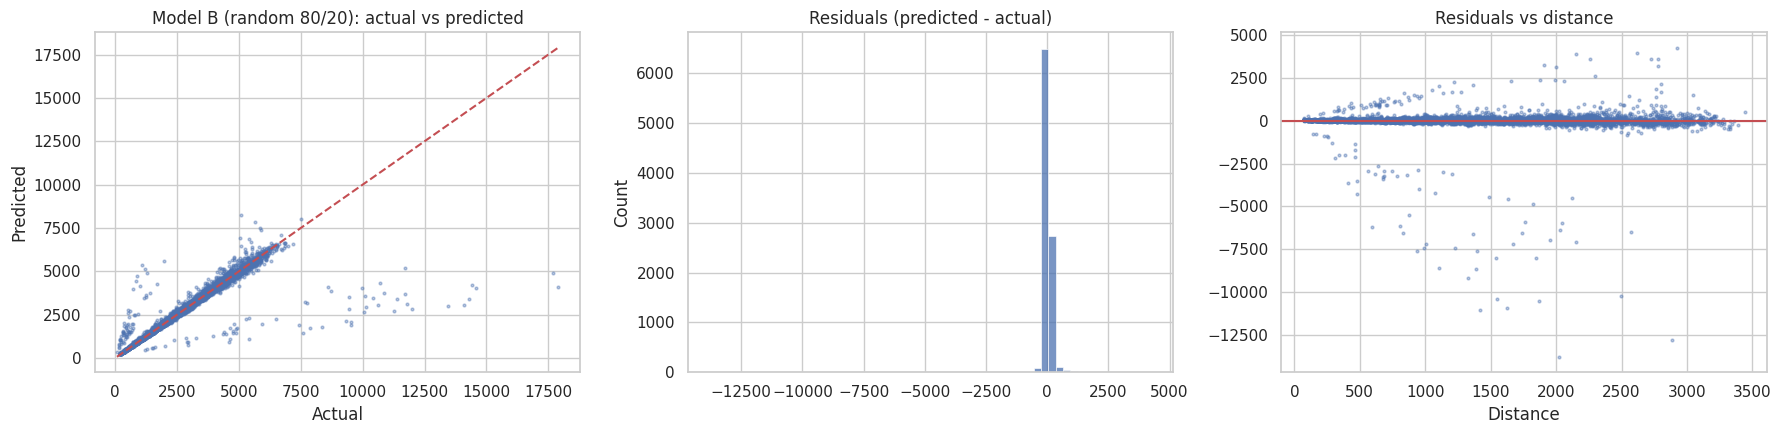

In [14]:
B_train, B_test = train_test_split(train_full, test_size=0.20, random_state=SEED, shuffle=True)
B_fit, B_early  = train_test_split(B_train, test_size=0.10, random_state=SEED, shuffle=True)   # early stopping only
print("Fit:", len(B_fit), "| early-stopping:", len(B_early), "| test (20%):", len(B_test))

resB = run_experiment("Model B (random 80/20)", B_fit, B_early, B_test)
R["B"] = resB["table"]; R["B_best_iter"] = resB["best_iter"]
R["B_sizes"] = (resB["n_fit"], resB["n_early"], resB["n_test"])
print("Best iteration:", resB["best_iter"])
display(resB["table"])
plot_results(resB, "fig_modelB.png")

## 8. Comparison of Model A and Model B

In [15]:
cmp_ = pd.concat({"A: last 3 days": resA["table"], "B: random 80/20": resB["table"]})
R["compare"] = cmp_
display(cmp_)

MAE      RMSE   MAPE_%   WAPE_%      Bias      R2
A: last 3 days  XGBoost                                153.4918  751.7982   8.1540   6.4906  -67.0591  0.7800
                Baseline: quote_signal x distance      436.1951  858.5443  23.3812  18.4452 -110.2194  0.7131
                Baseline: median rate/mile x distance  273.2013  772.0964  13.9433  11.5528   -2.0234  0.7679
B: random 80/20 XGBoost                                118.2524  536.8488   5.6077   4.9656    1.2805  0.8652
                Baseline: quote_signal x distance      224.9654  614.1799  11.2138   9.4466  -43.3565  0.8236
                Baseline: median rate/mile x distance  256.5750  603.4803  11.4479  10.7739   67.6395  0.8297

## 9. Model C: final model on all labeled data

The number of trees is the average of the best iterations from A and B, plus 10% because there is more data. The final model has no honest score of its own, since it has seen every labeled row, so the A and B results are the performance estimate.

In [16]:
n_trees = int(round(np.mean([resA["best_iter"], resB["best_iter"]]) * 1.10))
R["final_trees"] = n_trees
print("Final number of trees:", n_trees)

params_all, (all_f, val_f) = prepare(train_full, val)
final = xgb.XGBRegressor(n_estimators=n_trees, **XGB_PARAMS)
final.fit(all_f[FEATURES], all_f[TARGET])

R["final_insample"] = metrics(all_f[TARGET], final.predict(all_f[FEATURES]), "in-sample (not a test score)").round(4)

# XGBoost handles NaN natively (e.g. route_ratio when pickup and delivery coordinates are identical)
left = val_f[FEATURES].isna().sum(); left = left[left > 0]
print("NaN left in validation features:", left.to_dict() if len(left) else "none")

val_pred = final.predict(val_f[FEATURES])

# fill the template: same rows, same order, only predicted_rate changes
pred_by_id = pd.Series(val_pred, index=val[ID_COL].values)
out = template.copy()
out["predicted_rate"] = out[ID_COL].map(pred_by_id)
out[[ID_COL, "predicted_rate"]].to_csv(os.path.join(OUT_DIR, "validation_predictions.csv"), index=False)

checks = {
    "validation rows": len(out),
    "validation NaN": int(out["predicted_rate"].isna().sum()),
    "ids match template": bool(set(out[ID_COL]) == set(template[ID_COL])),
    "columns": list(out.columns),
    "min predicted validation": round(float(out["predicted_rate"].min()), 2),
}
R["checks"] = checks
for k, v in checks.items(): print(f"{k}: {v}")

Final number of trees: 116
NaN left in validation features: none
validation rows: 12000
validation NaN: 0
ids match template: True
columns: ['load_id', 'predicted_rate']
min predicted validation: 230.51


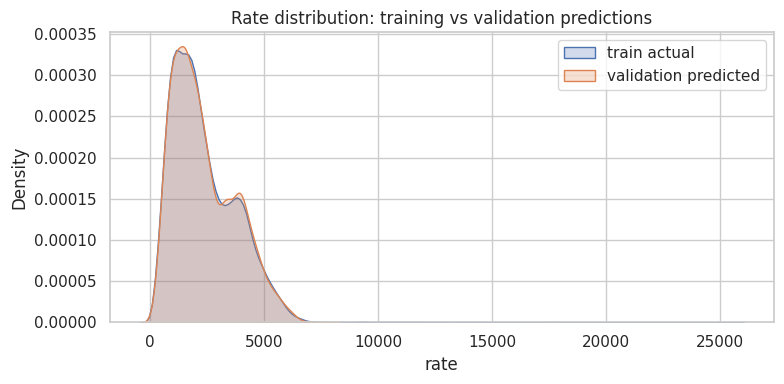

In [17]:
plt.figure(figsize=(8, 4))
sns.kdeplot(train_full[TARGET], label="train actual", fill=True, alpha=.25)
sns.kdeplot(val_pred, label="validation predicted", fill=True, alpha=.25)
plt.legend(); plt.title("Rate distribution: training vs validation predictions"); plt.xlabel("rate")
plt.tight_layout(); savefig("fig_pred_dist.png"); plt.show()

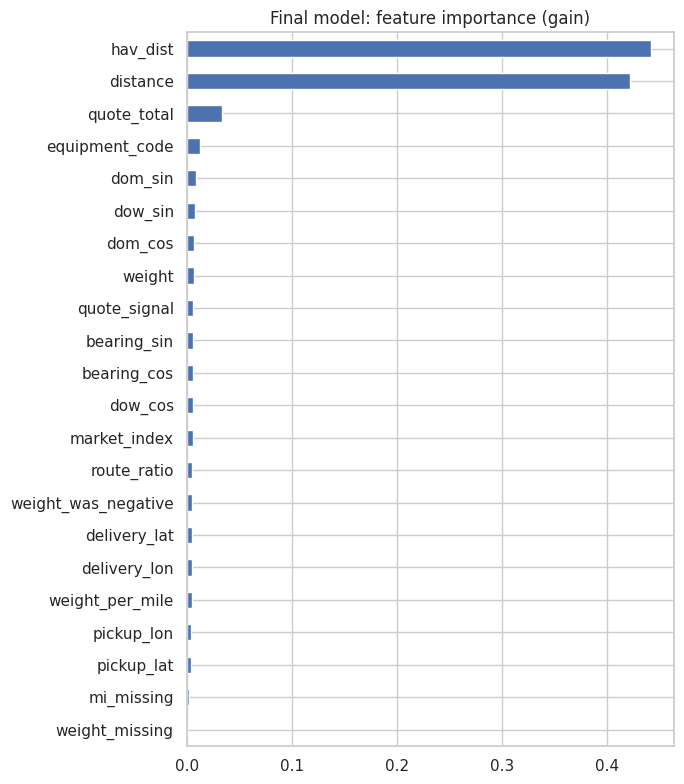

In [18]:
imp = pd.Series(final.feature_importances_, index=FEATURES).sort_values()
R["importance"] = imp.sort_values(ascending=False).round(4)

plt.figure(figsize=(7, 8)); imp.plot(kind="barh"); plt.title("Final model: feature importance (gain)")
plt.tight_layout(); savefig("fig_importance.png"); plt.show()